# Analytical Dye Misidentification Analysis

This section uses the **analytical approach** to characterize measurement noise:

1. **Extract fixed means** from highest-photon data (200k+ photons) - represents true dye signatures
2. **Fit covariances** at each photon level with fixed means (Soft EM) - characterizes measurement uncertainty
3. **Analytically calculate** misidentification rates from distribution overlap (Monte Carlo integration)

This is superior to the empirical approach because it:
- Separates signal (means = dye properties) from noise (covariances = measurement uncertainty)
- Directly models the noise at each photon level
- Provides stable, interpretable predictions of error rates

## Example Analyses with the New Databases

## Database Outputs

Three databases are created:

1. **Single Molecule Database** (`sm_db`): One row per molecule with averaged parameters
   - Includes `fov_index` and `fov_name` columns to track origin
   - `molecular_index` is globally unique across all FOVs

2. **Single Frame Database** (`sf_db`): One row per localization  
   - Includes `molecular_index` to link back to parent molecule
   - Includes `fov_index` and `fov_name`

3. **Photon Accumulation Database** (`pa_db`): One row per molecule per accumulated frame
   - Shows how A_R, A_G, A_B evolve as photons accumulate
   - Enables precision vs photon count analysis

# Multi-FOV Analysis with New Wrapper Functions

The new `analyze_multi_fov_dataset()` function provides a complete workflow for:
1. Processing multiple FOV localization files
2. Tracking which FOV each molecule came from
3. Building photon accumulation databases for precision analysis

This replaces the manual per-file processing shown above with a single function call.

In [113]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

from src.DriftCorrectionFunctions import (
    Drift_Correction_Functions,
    DriftMethod,
    DriftParameters,
    DriftResult,
)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [114]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [115]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [116]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [117]:
dye_data_folders = np.array([r'C:\Users\kbhc756\temp_data\20251125_btc_analysis\ATTO565_594\2025_11_27\2p5pM_10perc561_568LP_1'])

In [118]:
localisation_files = H_F.file_search(dye_data_folders[0], ".h5", "Pos")

In [119]:
localisation_files

['C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_000.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_000_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_001.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_001_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_002.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_002_undrifted_locs.h5',
 'C:\\Users\\kbhc75

In [33]:
len(localisation_files)

16

### define some common parameters

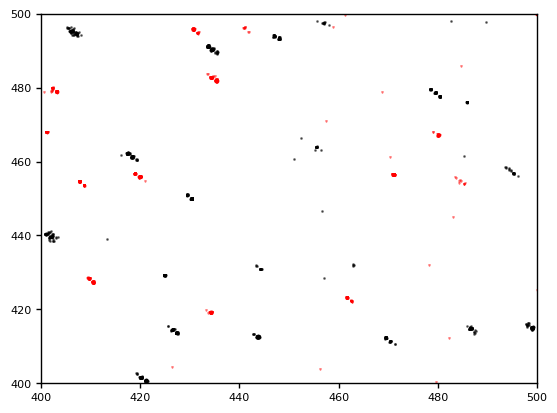

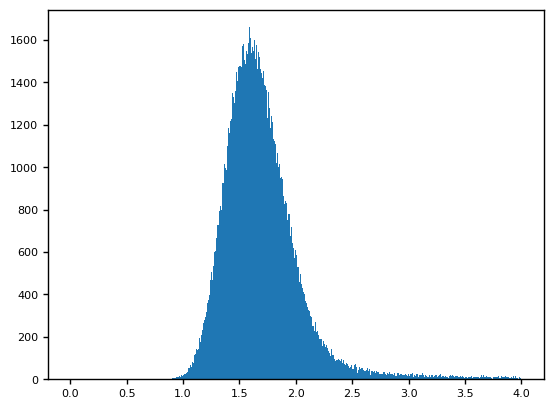

In [37]:
test_locs = pd.read_hdf(localisation_files[0])
frame = 0
for i in np.arange(100):
    plt.scatter(test_locs['xc'][test_locs['frame']==frame+i],test_locs['yc'][test_locs['frame']==frame+i], alpha=0.5, s=1, color='k')
    plt.scatter(corrected_locs['xc'][corrected_locs['frame']==frame+i],corrected_locs['yc'][corrected_locs['frame']==frame+i], alpha=0.5, s=1,
                color='red', marker='v')
    
plt.xlim([400, 500])
plt.ylim([400,500])
plt.show()
plt.hist(test_locs['chi_sqr'],np.linspace(0,4,1000))
plt.show()

In [41]:
print(np.median(test_locs['chi_sqr']))

1.65321


In [34]:
min_cluster_size = 5
chi_val = 2
max_localisation_error = 0.5
min_photons = 100
max_photons = 1e6
max_distance = 0.5

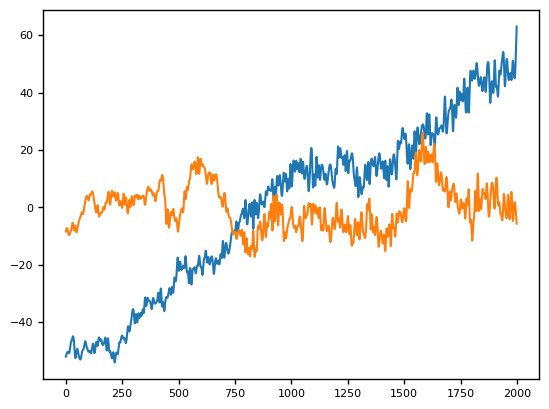

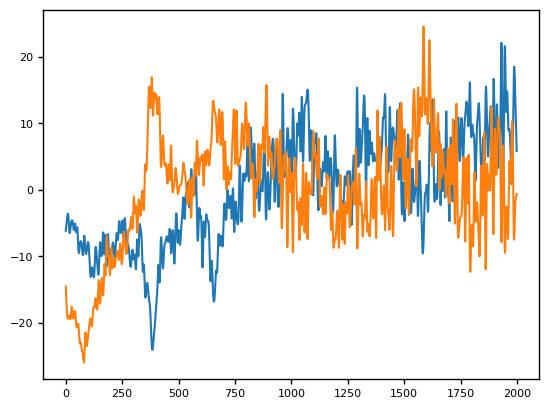

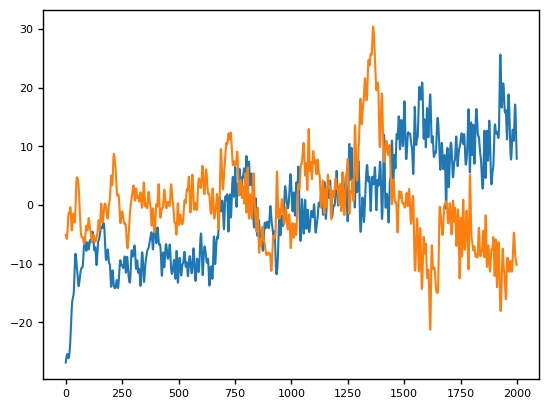

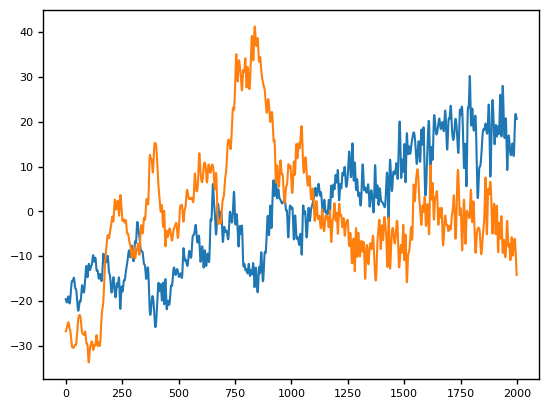

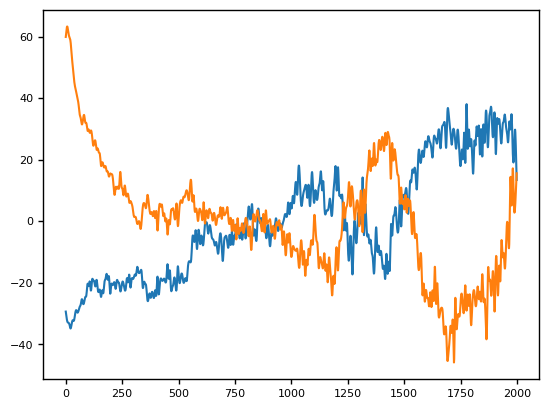

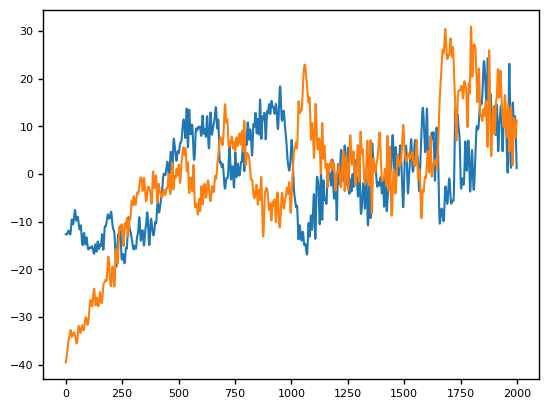

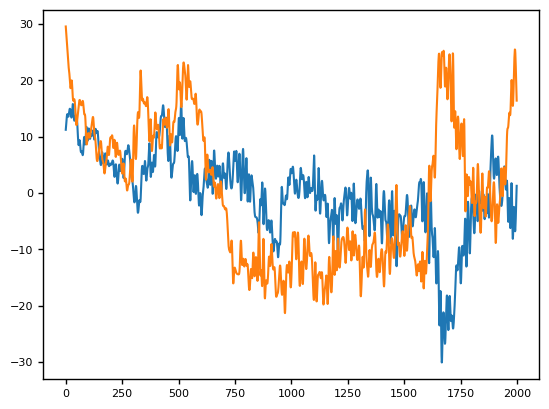

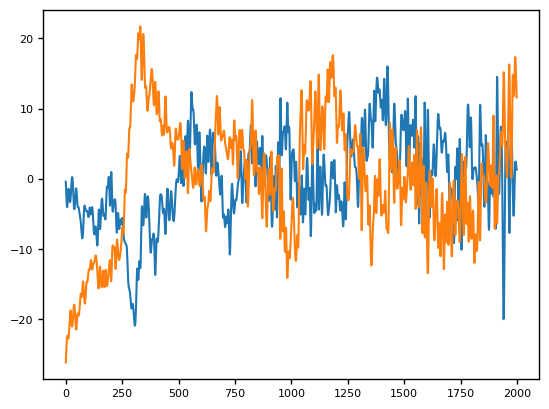

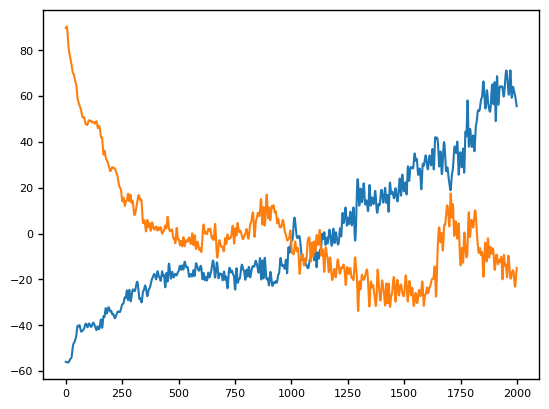

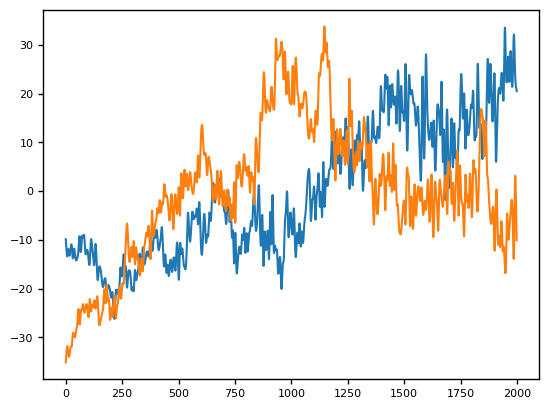

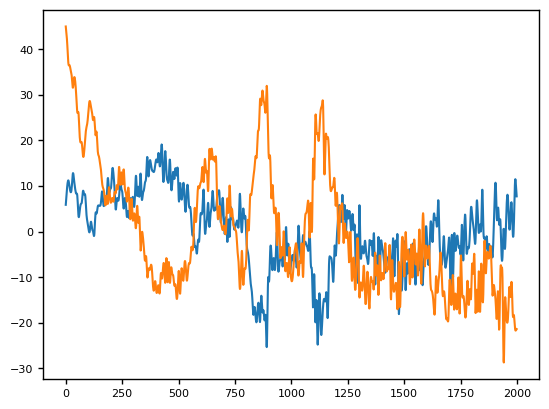

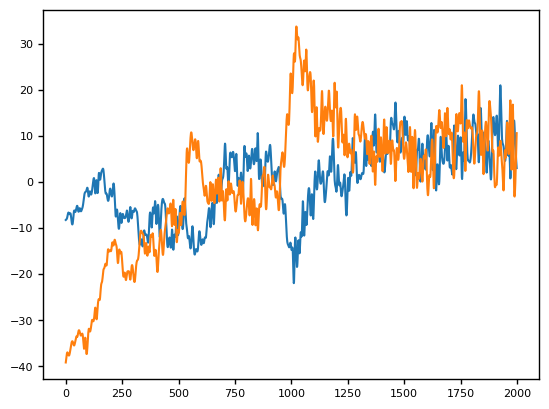

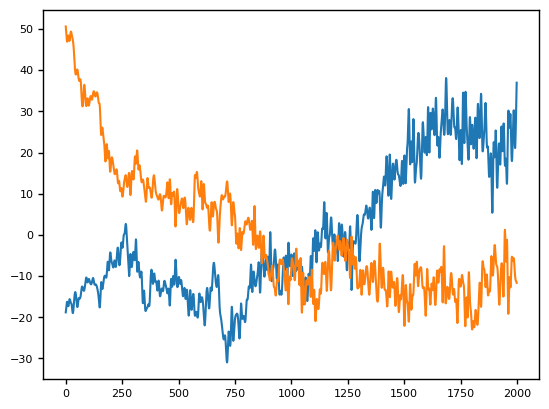

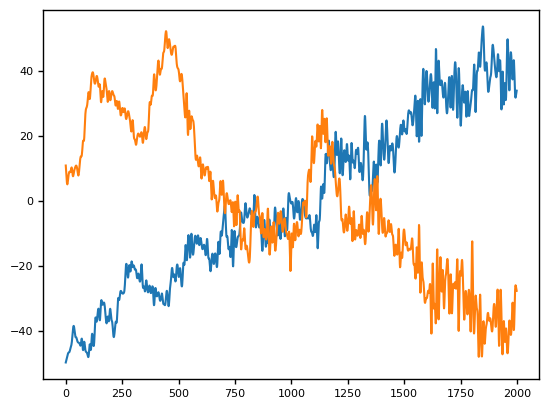

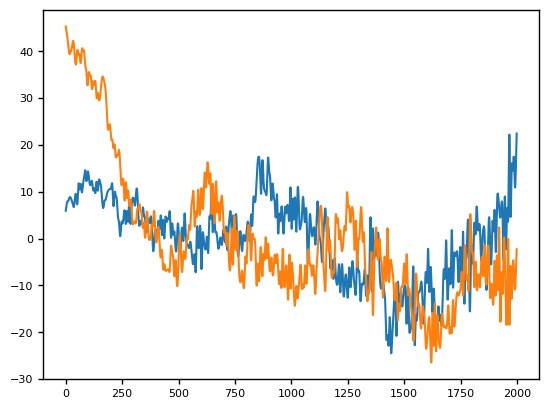

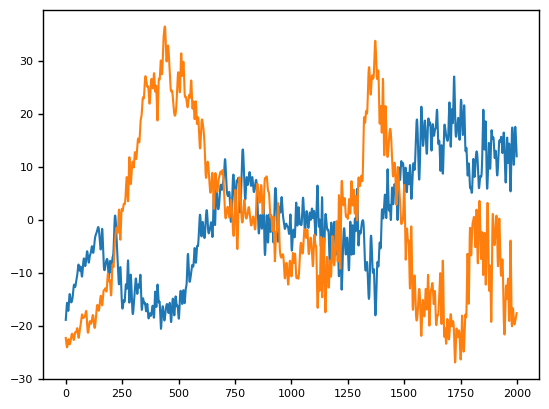

In [35]:
for i in np.arange(16):
    test_locs = pd.read_hdf(localisation_files[i])
    DCF = Drift_Correction_Functions()
    metadata_files = H_F.file_search(dye_data_folders[0], "metadata", "")
    x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
    n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])
    method = 'aim'
    info = [{
        "Width": float(width),
        "Height": float(height),
        "Frames": float(n_frames),
        "Pixelsize": 69.0  # nm per pixel
    }]
    
    params = {
                        "segmentation": 5,  # Larger segments for AIM
                        "intersect_d": 0.5,   # Intersection distance
                        "roi_r": 2.0          # Search radius
                    }
    corrected_locs, drift_result = DCF.undrift(
                    test_locs.to_records(index=False), info, method=method, **params
                )
    corrected_locs = pd.DataFrame(corrected_locs)
    
    plt.plot(drift_result.drift_x*69)
    plt.plot(drift_result.drift_y*69)
    plt.show()
    
    # save corrected localisations
    IO._write_h5_database(
        corrected_locs,
        os.path.join(
            dye_data_folders[0], localisation_files[i].split(".h5")[0] + "_undrifted_locs.h5"
        ),
        normalise_photons=False,
        append=False
    )

In [120]:
localisation_files = H_F.file_search(dye_data_folders[0], "_undrifted_locs.h5", "Pos")

In [121]:
localisation_files

['C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_000_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_001_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_002_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos000_003_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos001_000_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO565_594\\2025_11_27\\2p5pM_10perc561_568LP_1\\2p5pM_10perc561_568LP_1_MMStack_2-Pos00

In [44]:
# Example 1: Complete multi-FOV analysis with photon accumulation
# This single function call does everything:
# - Clusters molecules in each FOV
# - Tracks FOV origin for each molecule
# - Builds photon accumulation database
# - Saves all results to disk

sm_db, sf_db, pa_db = SM_E.analyse_multi_fov_dataset(
    localisation_files,  # List of all FOV .h5 files
    clustering_method="DBSCAN",
    build_accumulation=True,
    min_cluster_size=min_cluster_size,
    max_localisation_error=max_localisation_error,
    chi_val=chi_val,
    min_photons=min_photons,
    max_photons=max_photons,
    output_folder=dye_data_folders[0],
    output_prefix="dye_mixture_analysis",
    verbose=True
)

Multi-FOV Single Molecule Analysis
 266581 localizations... Found 212 molecules_MMStack_2-Pos000_000_undrifted_locs.h5)...
 174905 localizations... Found 139 molecules_MMStack_2-Pos000_001_undrifted_locs.h5)...
 273115 localizations... Found 249 molecules_MMStack_2-Pos000_002_undrifted_locs.h5)...
 246891 localizations... Found 181 molecules_MMStack_2-Pos000_003_undrifted_locs.h5)...
 238493 localizations... Found 221 molecules_MMStack_2-Pos001_000_undrifted_locs.h5)...
 221859 localizations... Found 214 molecules_MMStack_2-Pos001_001_undrifted_locs.h5)...
 241917 localizations... Found 183 molecules_MMStack_2-Pos001_002_undrifted_locs.h5)...
 216993 localizations... Found 149 molecules_MMStack_2-Pos001_003_undrifted_locs.h5)...
 222545 localizations... Found 258 molecules_MMStack_2-Pos002_000_undrifted_locs.h5)...
 209478 localizations... Found 246 molecules1_MMStack_2-Pos002_001_undrifted_locs.h5)...
 201292 localizations... Found 237 molecules1_MMStack_2-Pos002_002_undrifted_locs.h5

In [122]:
folder = dye_data_folders[0]
sm_db = pd.read_hdf(os.path.join(folder, 'dye_mixture_analysis_single_molecules.h5'))
sf_db = pd.read_hdf(os.path.join(folder, 'dye_mixture_analysis_single_frames.h5'))
pa_db = pd.read_hdf(os.path.join(folder, 'dye_mixture_analysis_photon_accumulation.h5'))

In [123]:
len(sm_db)

3611

In [47]:
molecular_indices = np.unique(sm_db['molecular_index'])

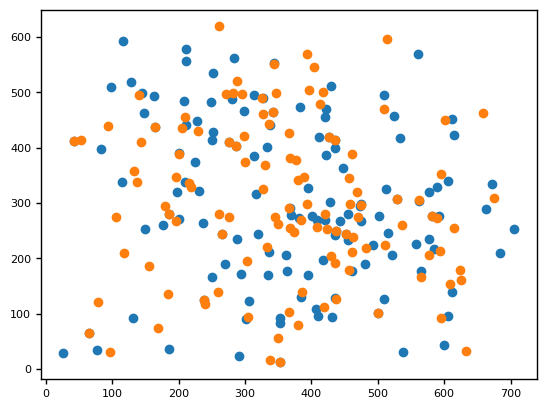

In [48]:
frame = 100
plt.scatter(sf_db['xc'][sf_db['frame']==frame],sf_db['yc'][sf_db['frame']==frame])
plt.scatter(sf_db['xc'][sf_db['frame']==frame+1],sf_db['yc'][sf_db['frame']==frame+1])

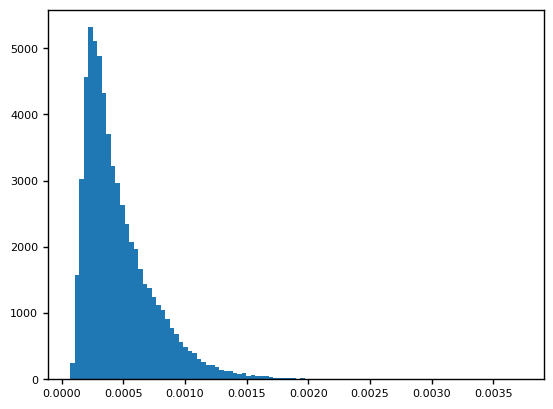

In [49]:
plt.hist(sf_db['A_G_err'], 100);
plt.show()

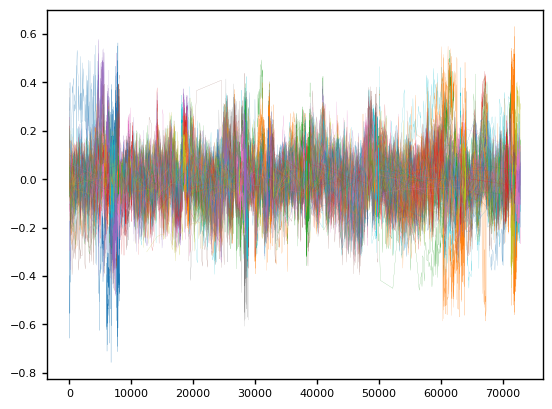

In [224]:
for index in molecular_indices:
    test = sf_db[sf_db['molecular_index'] == index]
    plt.plot(test['xc']-np.median(test['xc'].to_numpy()), lw=0.1)
plt.show()

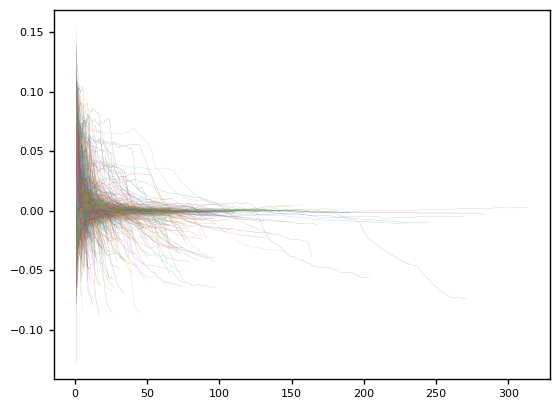

In [50]:
for index in molecular_indices:
    test = pa_db[pa_db['molecular_index'] == index]
    plt.plot(test['frames_accumulated'], test['A_R']-np.median(test['A_R'].to_numpy()), lw=0.1)
plt.show()

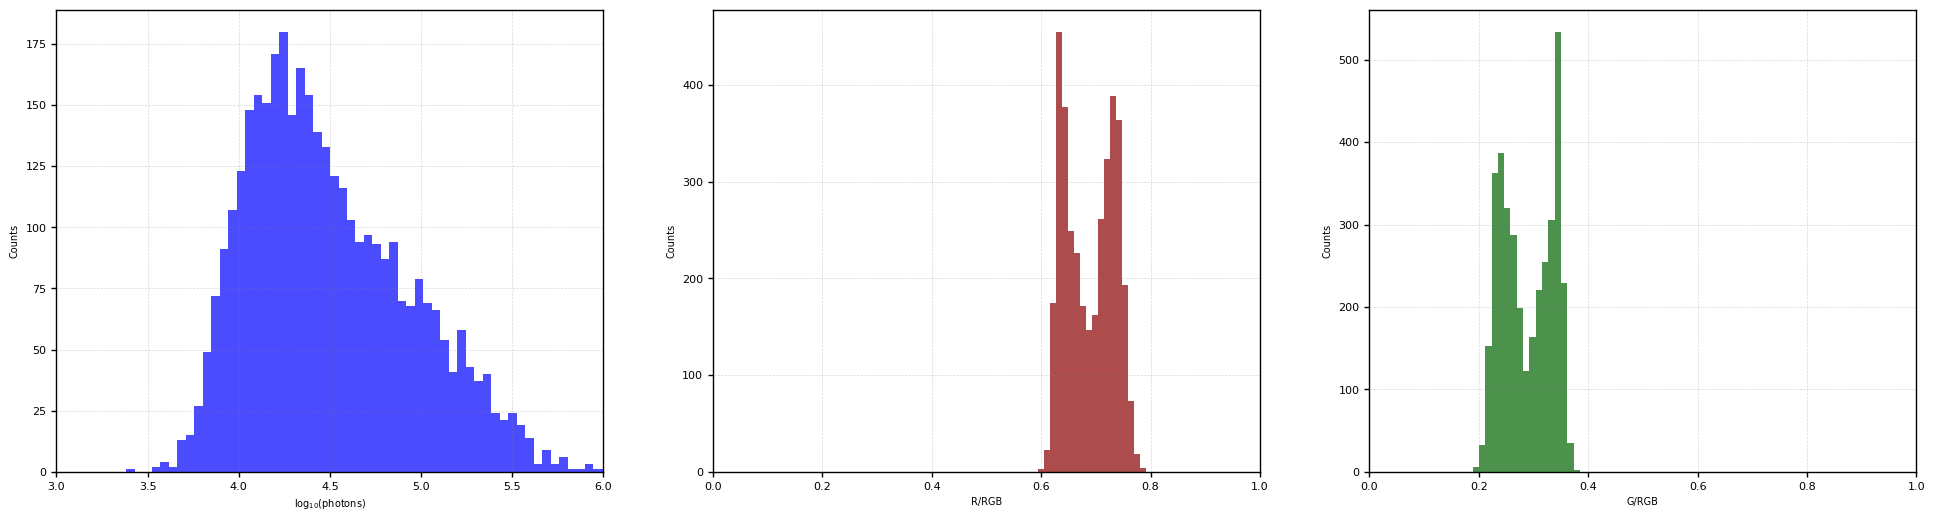

In [80]:
fig, axs = plotter.create_subplots(ncols=3)


bins = np.histogram_bin_edges(np.log10(sm_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sm_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)')


bins = np.histogram_bin_edges(sm_db['A_R'].to_numpy(), 'fd')
axs[1] = plotter.histogram_plot(axs[1], sm_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
bins = np.histogram_bin_edges(sm_db['A_G'].to_numpy(), 'fd')
axs[2] = plotter.histogram_plot(axs[2], sm_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')

axs[0].set_xlim([3, 6])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
folder = r'C:\Users\kbhc756\temp_data\20251125_btc_analysis\ATTO565_594\2025_11_27\2p5pM_10perc561_568LP_1'
plt.savefig(os.path.join(folder, 'Dye_Mixtures_perMolecule.svg'), dpi=600, format='svg')

plt.show()

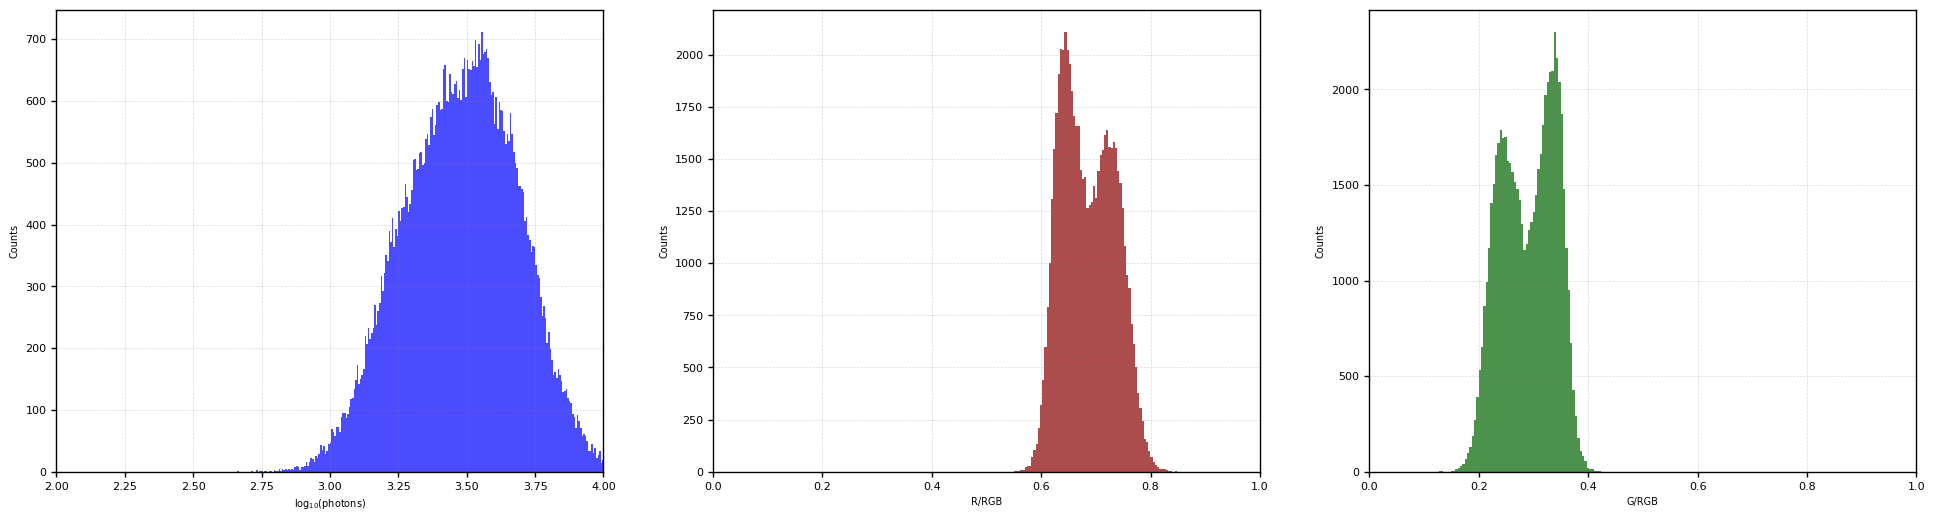

In [81]:
fig, axs = plotter.create_subplots(ncols=3)


bins = np.histogram_bin_edges(np.log10(sf_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sf_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)')


bins = np.histogram_bin_edges(sf_db['A_R'].to_numpy(), 'fd')
axs[1] = plotter.histogram_plot(axs[1], sf_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
bins = np.histogram_bin_edges(sf_db['A_G'].to_numpy(), 'fd')
axs[2] = plotter.histogram_plot(axs[2], sf_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')

axs[0].set_xlim([2, 4])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
plt.savefig(os.path.join(folder, 'Dye_Mixtures_perFrame.svg'), dpi=600, format='svg')

plt.show()

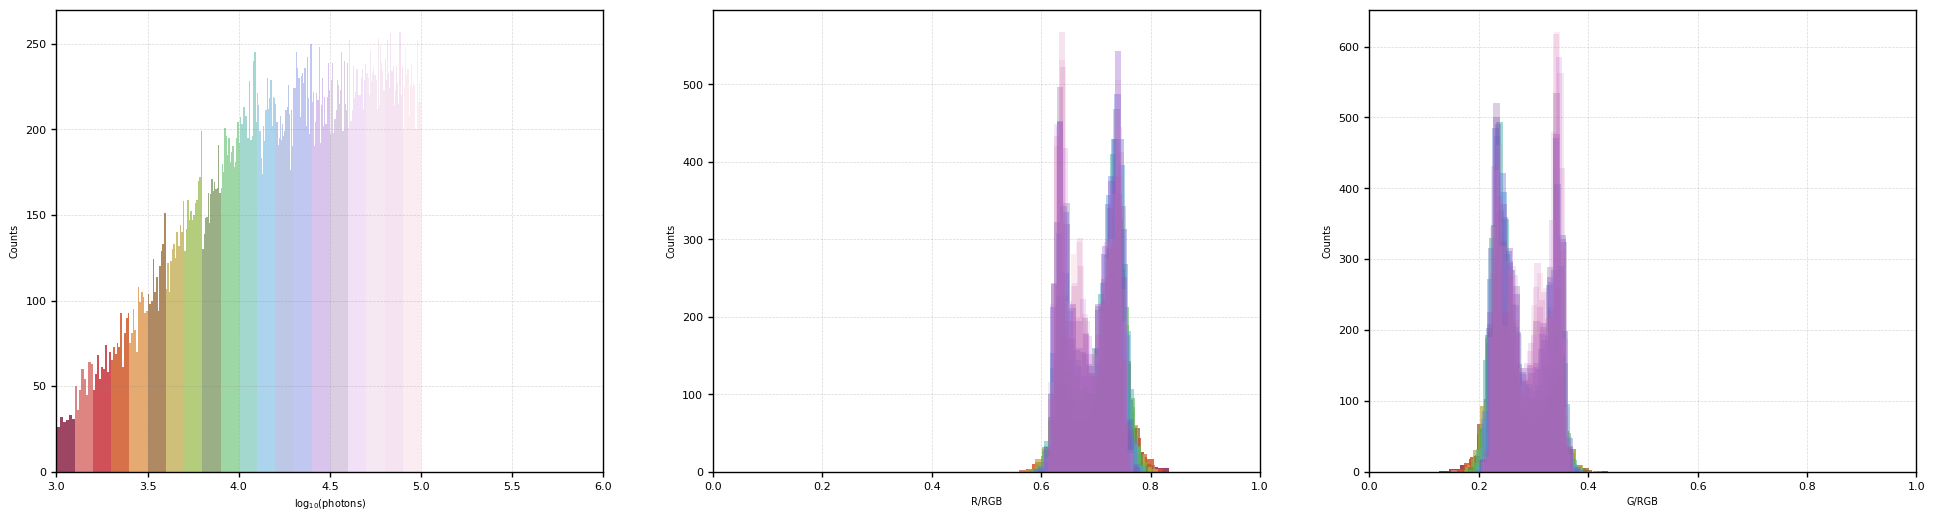

In [82]:
fig, axs = plotter.create_subplots(ncols=3)

filter_levels = np.logspace(3, 5, 21)

cs = ["#9d4663",
"#dd7e7d",
"#cb3f46",
"#d05a2b",
"#df974e",
"#966531",
"#bea643",
"#8fb43c",
"#5c7e3c",
"#55ba63",
"#4eb5a0",
"#52a7d8",
"#6880c5",
"#5c6fda",
"#9052ca",
"#84549c",
"#cc7de4",
"#d18cc6",
"#c548a8",
"#d94882"]

alpha_gradient = np.linspace(1, 0.1, 20)

for i in np.arange(len(filter_levels[:-1])):
    filtered = pa_db[
          (pa_db['photons_accumulated'] >= filter_levels[i]) &
          (pa_db['photons_accumulated'] < filter_levels[i+1])
      ]
    bins = np.histogram_bin_edges(np.log10(filtered['photons_accumulated'].to_numpy()), 'fd')
    axs[0] = plotter.histogram_plot(axs[0], np.log10(filtered['photons_accumulated']), bins, density=False, 
                                    color=cs[i], xlabel=r'log$_{10}$(photons)',
                                   alpha=alpha_gradient[i])

    
    bins = np.histogram_bin_edges(filtered['A_R'].to_numpy(), 'fd')
    axs[1] = plotter.histogram_plot(axs[1], filtered['A_R'], bins, 
                                    alpha=alpha_gradient[i], color=cs[i],
                                   xlabel='R/RGB')
    bins = np.histogram_bin_edges(filtered['A_G'].to_numpy(), 'fd')
    axs[2] = plotter.histogram_plot(axs[2], filtered['A_G'], bins, 
                                    alpha=alpha_gradient[i], color=cs[i],
                                   xlabel='G/RGB')

axs[0].set_xlim([3, 6])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])

plt.savefig(os.path.join(folder, 'Dye_Mixtures_vs_Photons.svg'), dpi=600, format='svg')
plt.show()

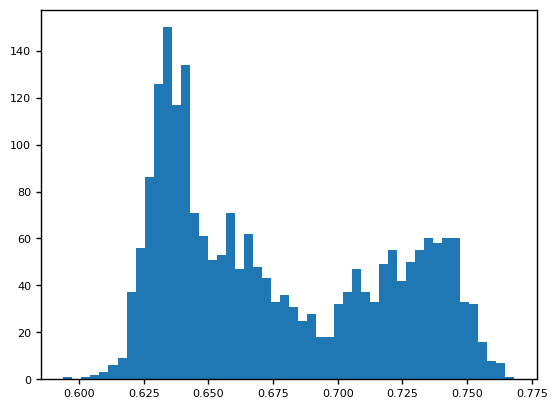

In [127]:
plt.hist(sm_db['A_R'][sm_db['photons'] > 20000][sm_db['A_R'] > 0.55][sm_db['A_G'] > 0.15], 50);
plt.show()

Extracting Reference Means (Analytical Approach)
Mode: Single Molecule Database
Using all molecules (no photon threshold)
Total molecules in database: 3611

Fitting 2-component Gaussian Mixture Model...
  Covariance type: full
  Features: A_R, A_G
  MLE optimization: downsampled to 3908 samples for tractability
  Using error-weighted GMM fitting (1/σ weighting from A_R_err, A_G_err columns)
    Photon range: 2415 - 1672551
    Uncertainty range: σ=0.0001 - 0.0029
    Weight range: 0.20 - 4.71
    Replication range: 1 - 24 copies
    Original samples: 3611, Weighted samples: 3908
  Histogram-based initialization:
    Component 0: A_R=0.6317, A_G=0.3475
    Component 1: A_R=0.7349, A_G=0.2339
  Running MLE optimization (L-BFGS-B)...
  Converged: True
  BIC: -40291.09
  AIC: -40359.20

GMM Component Parameters:
  Component 0:
    Mean A_R: 0.6456
    Mean A_G: 0.3341
    Weight: 0.5117
    Molecules assigned: 1712 (47.4%)
  Component 1:
    Mean A_R: 0.7271
    Mean A_G: 0.2493
    Weight

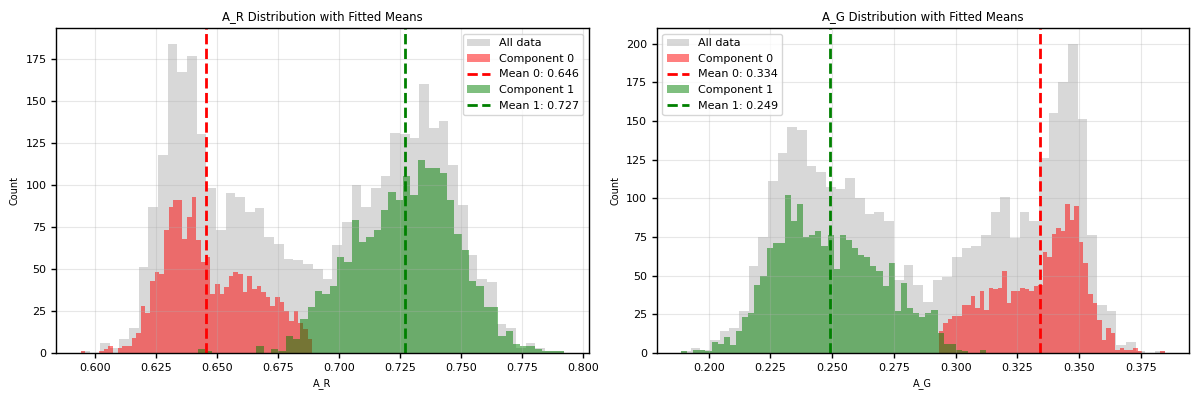


  (Close the plot window to continue)

Fixed means extracted from 3611 high-photon molecules:
  Component 0: A_R=0.6456, A_G=0.3341
  Component 1: A_R=0.7271, A_G=0.2493

These means will be held fixed while analyzing noise at lower photon levels.


In [78]:
# Step 1: Extract reference means from highest-photon data (Analytical Approach)
# Uses all molecules to establish fixed mean positions
# These means represent the true dye RGB signatures (signal), not measurement noise

fixed_means, ref_db, gmm = SM_E.extract_reference_means(
    sm_db[sm_db['photons'] > 2000][sm_db['A_R'] > 0.55][sm_db['A_G'] > 0.15],
    reference_photon_threshold=None,
    n_components=2,
    covariance_type="full",
    fit_type="MLE",
    verbose=True
)

print(f"\nFixed means extracted from {len(ref_db)} high-photon molecules:")
print(f"  Component 0: A_R={fixed_means[0,0]:.4f}, A_G={fixed_means[0,1]:.4f}")
print(f"  Component 1: A_R={fixed_means[1,0]:.4f}, A_G={fixed_means[1,1]:.4f}")
print(f"\nThese means will be held fixed while analyzing noise at lower photon levels.")

Analytical Misidentification Analysis
Photon bins: 19 bins
  Range: 1,000 - 50,000 photons
Reference molecules: 3611
Fixed means: 2 components

Photon accumulation rows (reference molecules only): 62407

Bin 1/19: [1,000, 1,229) photons...
  Molecules in bin: 159
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


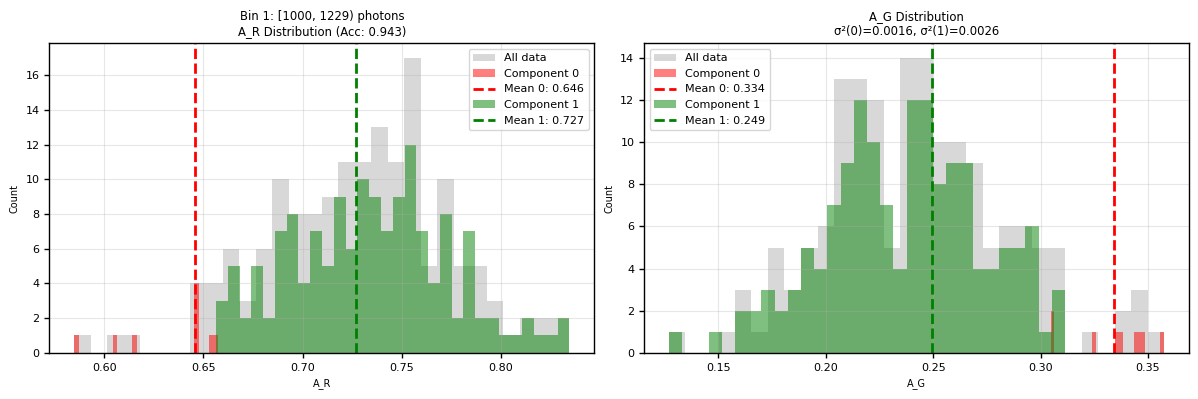

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.943
  Component accuracies: [ 0.75463  0.97129]

Bin 2/19: [1,229, 1,510) photons...
  Molecules in bin: 339
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


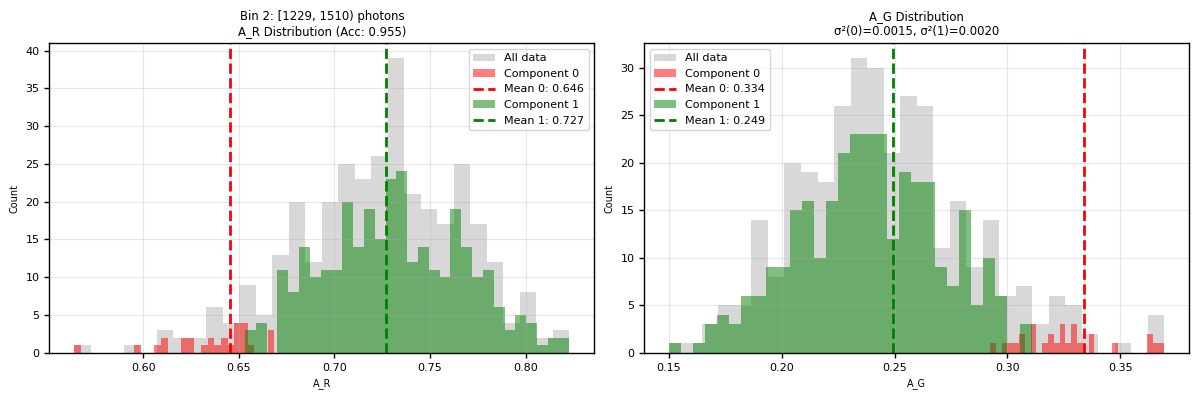

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.955
  Component accuracies: [ 0.80689  0.97826]

Bin 3/19: [1,510, 1,855) photons...
  Molecules in bin: 461
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


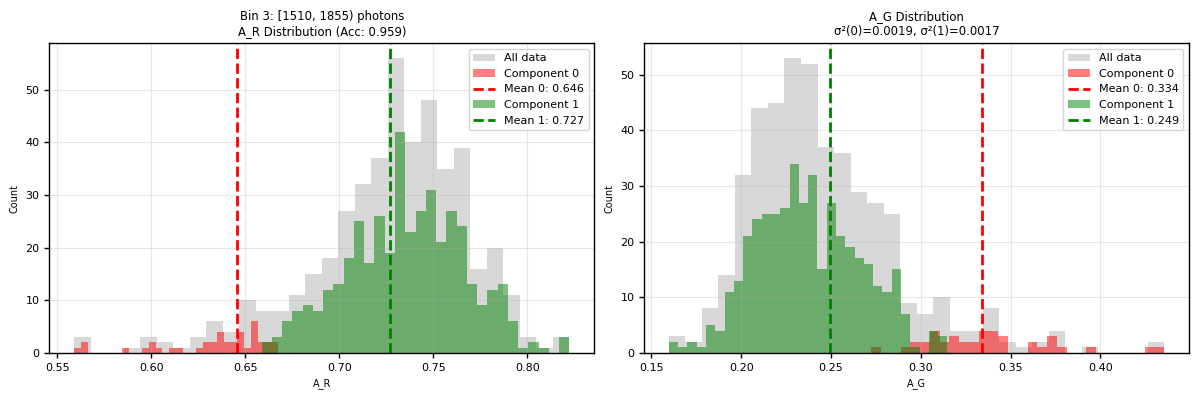

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.959
  Component accuracies: [ 0.78229  0.98347]

Bin 4/19: [1,855, 2,279) photons...
  Molecules in bin: 624
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


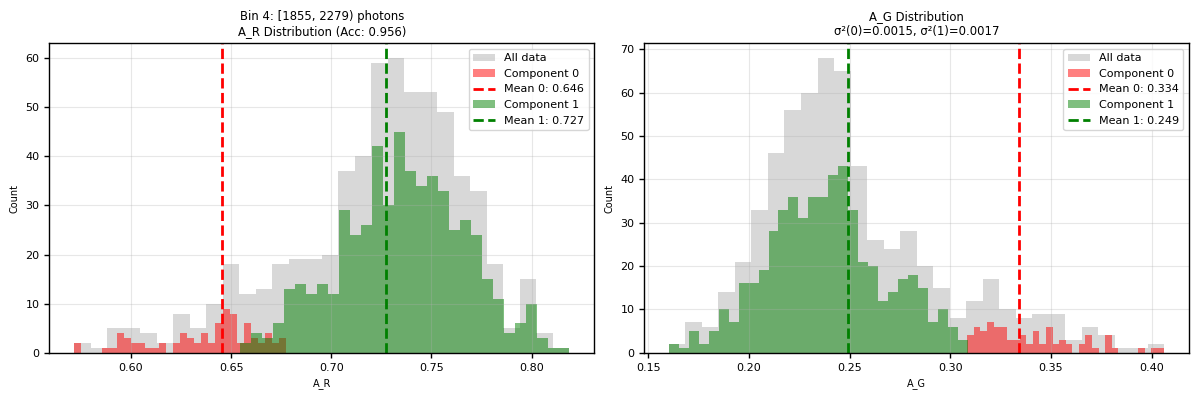

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.956
  Component accuracies: [ 0.84562  0.97849]

Bin 5/19: [2,279, 2,800) photons...
  Molecules in bin: 761
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


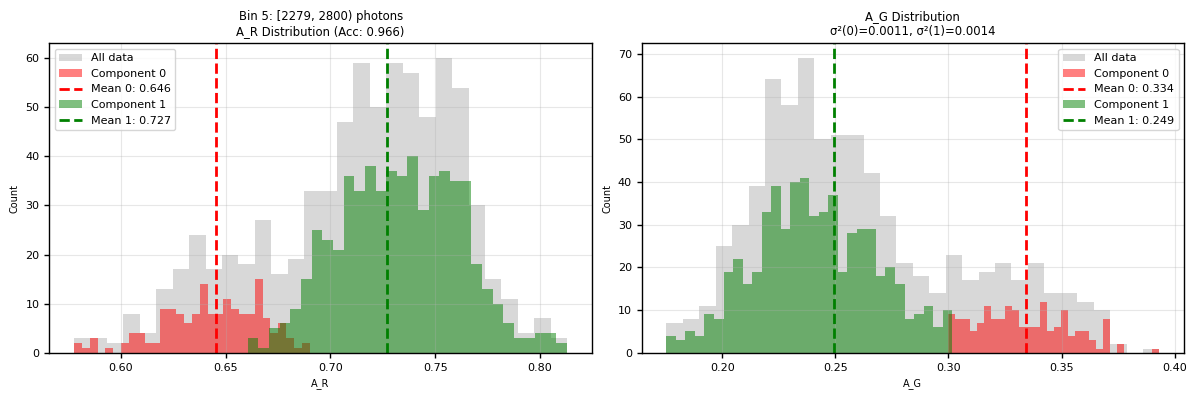

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.966
  Component accuracies: [ 0.92719  0.97856]

Bin 6/19: [2,800, 3,440) photons...
  Molecules in bin: 1011
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


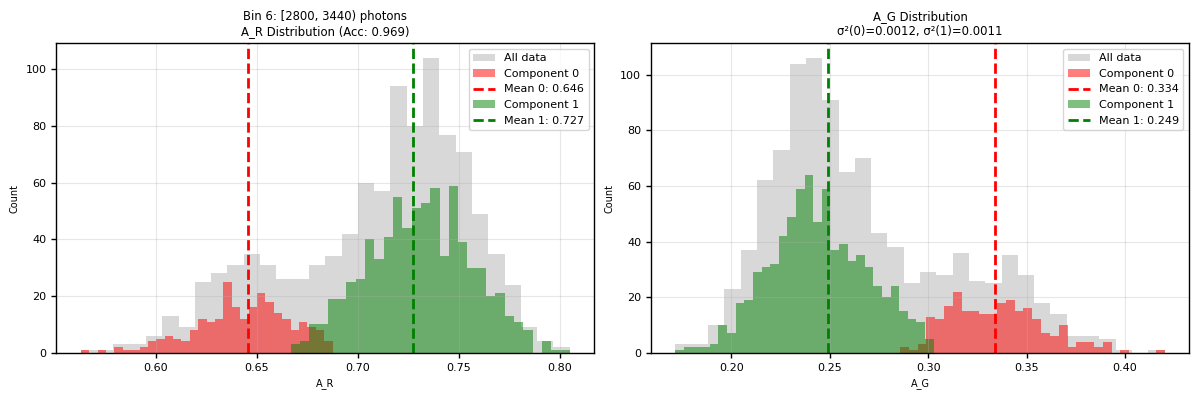

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.969
  Component accuracies: [ 0.93415  0.98156]

Bin 7/19: [3,440, 4,226) photons...
  Molecules in bin: 1186
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


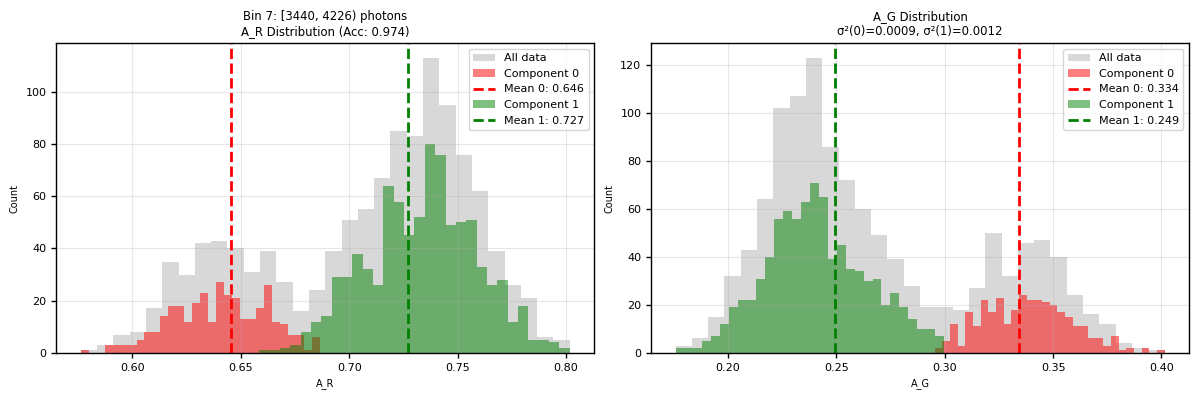

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.974
  Component accuracies: [ 0.95494  0.98201]

Bin 8/19: [4,226, 5,192) photons...
  Molecules in bin: 1461
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


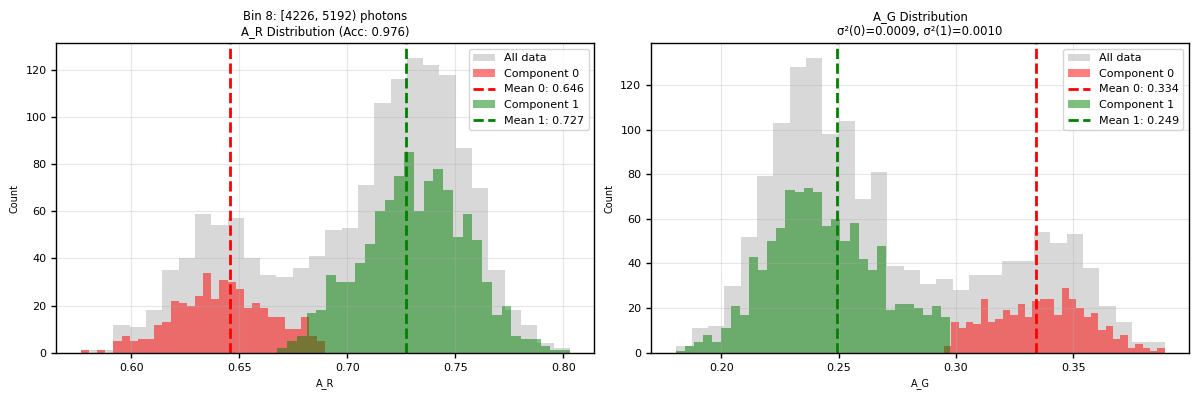

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.976
  Component accuracies: [ 0.95859  0.9839 ]

Bin 9/19: [5,192, 6,379) photons...
  Molecules in bin: 1699
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


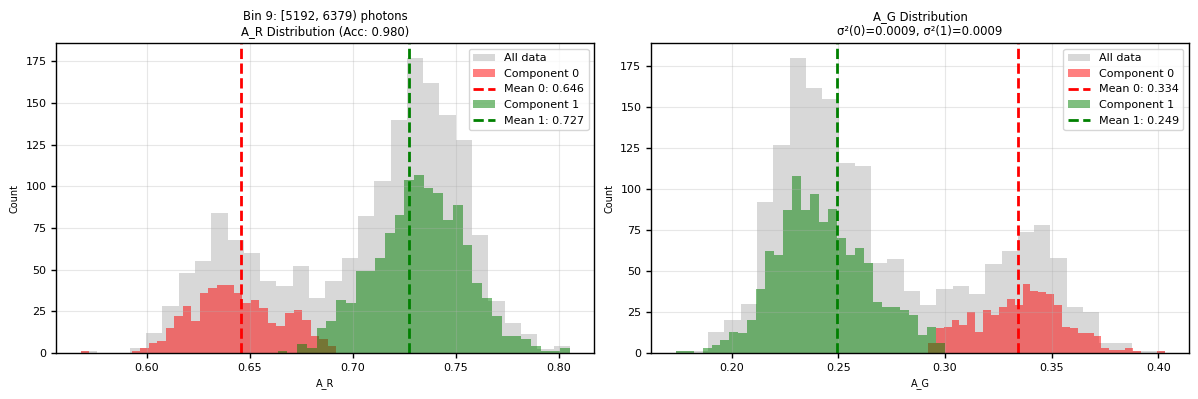

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.980
  Component accuracies: [ 0.96617  0.98677]

Bin 10/19: [6,379, 7,838) photons...
  Molecules in bin: 1969
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


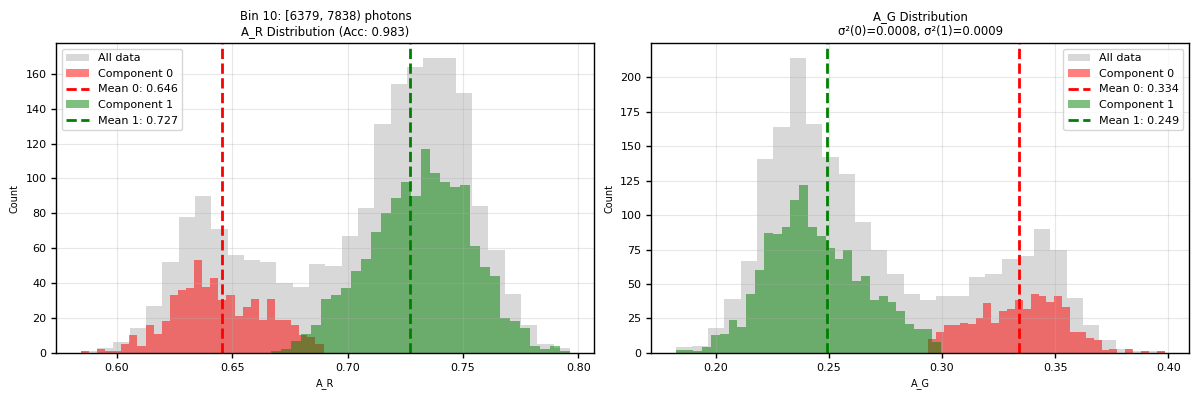

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.983
  Component accuracies: [ 0.97116  0.98879]

Bin 11/19: [7,838, 9,630) photons...
  Molecules in bin: 2207
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


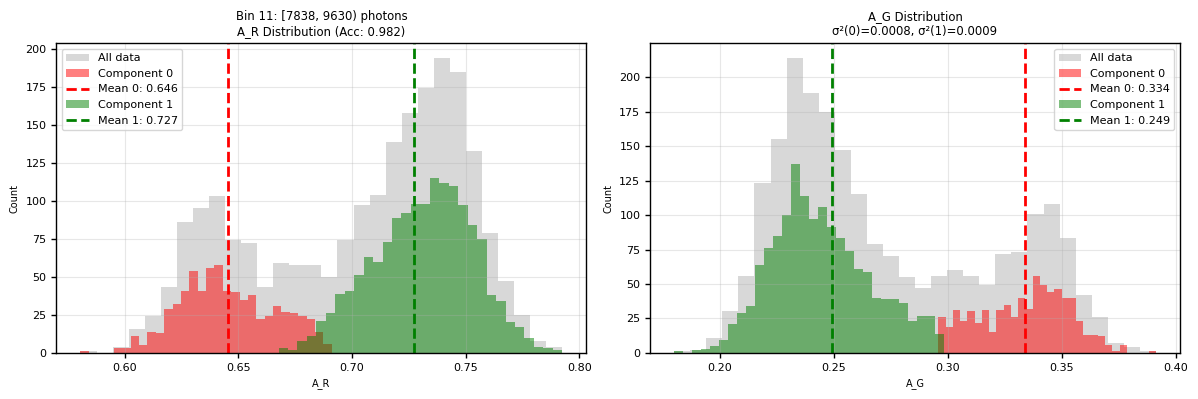

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.982
  Component accuracies: [ 0.97169  0.98705]

Bin 12/19: [9,630, 11,831) photons...
  Molecules in bin: 2334
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


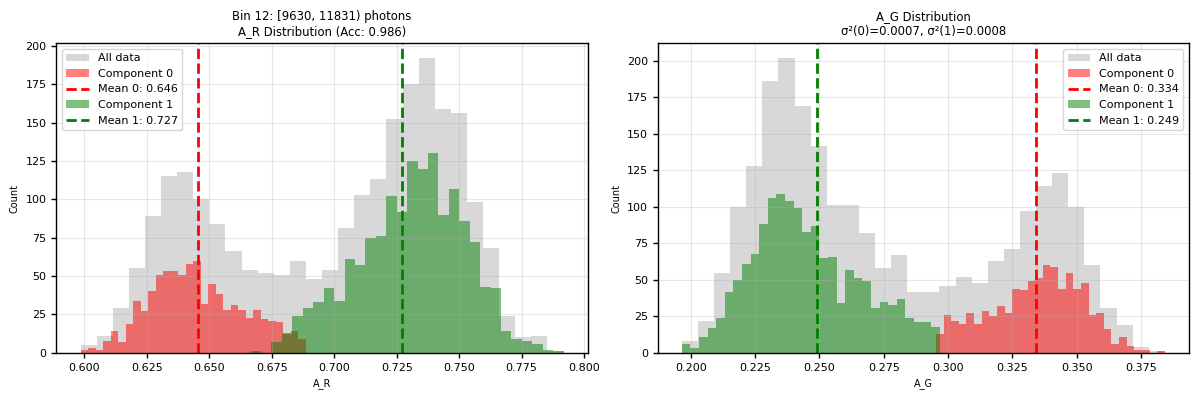

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.986
  Component accuracies: [ 0.98166  0.98927]

Bin 13/19: [11,831, 14,536) photons...
  Molecules in bin: 2383
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


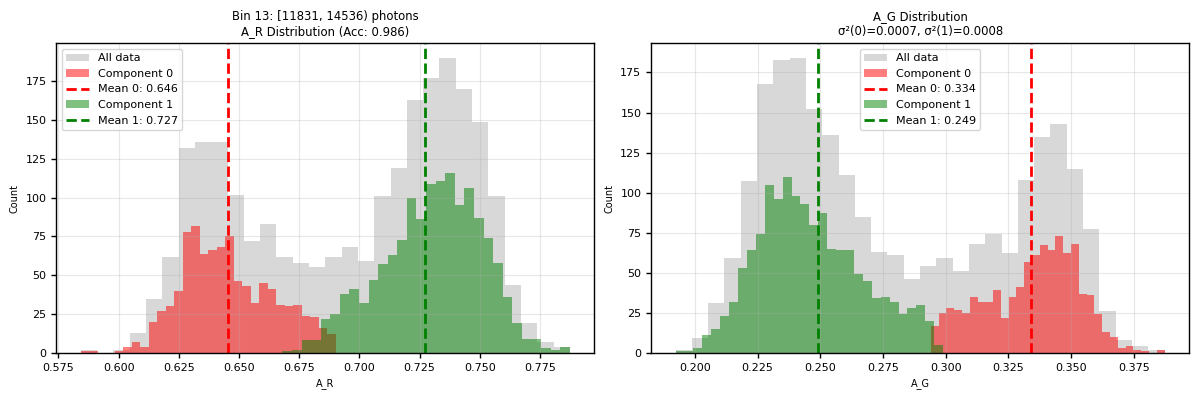

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.986
  Component accuracies: [ 0.98289  0.9886 ]

Bin 14/19: [14,536, 17,860) photons...
  Molecules in bin: 2333
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


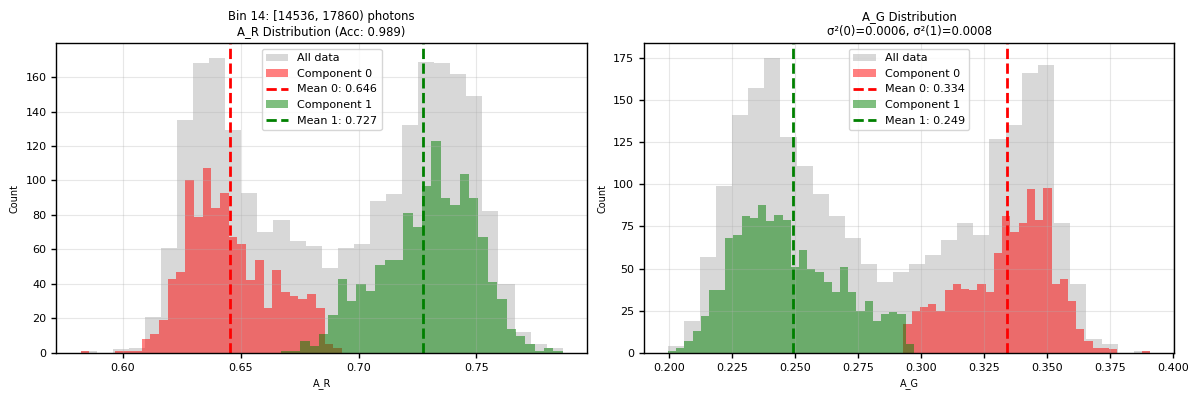

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.989
  Component accuracies: [ 0.9881   0.98931]

Bin 15/19: [17,860, 21,943) photons...
  Molecules in bin: 2198
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


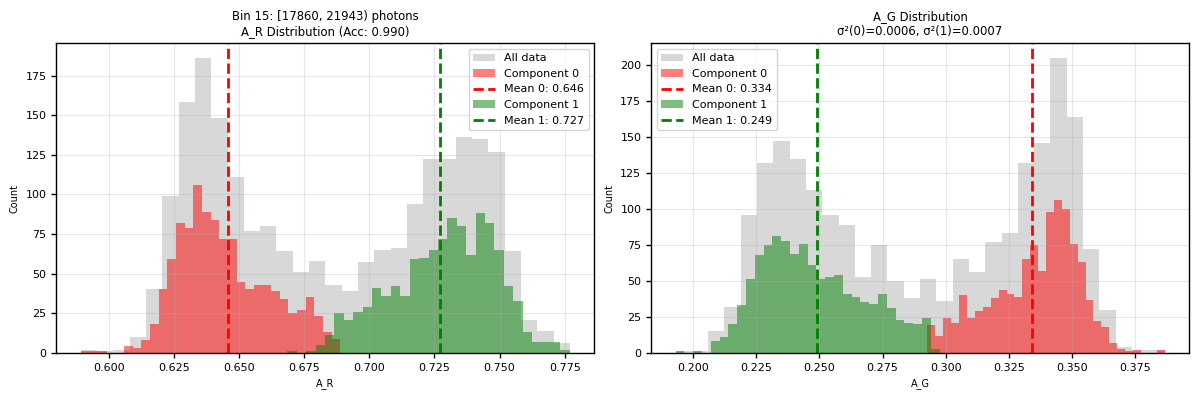

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.990
  Component accuracies: [ 0.99064  0.98948]

Bin 16/19: [21,943, 26,959) photons...
  Molecules in bin: 1964
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


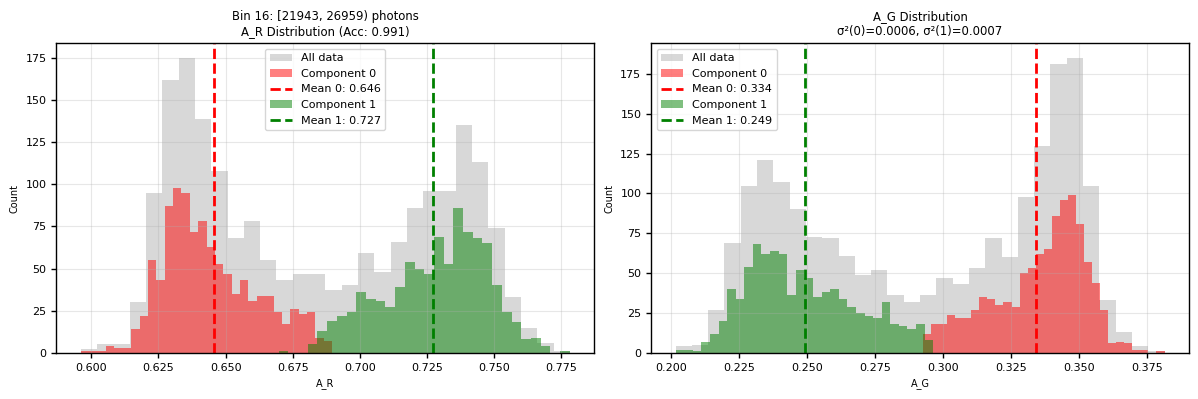

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.991
  Component accuracies: [ 0.99213  0.98954]

Bin 17/19: [26,959, 33,123) photons...
  Molecules in bin: 1736
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


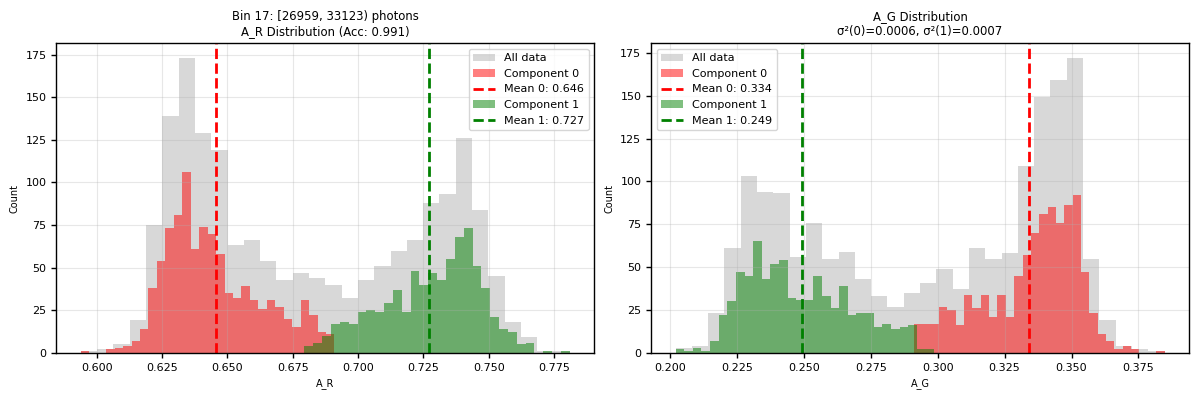

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.991
  Component accuracies: [ 0.99248  0.98918]

Bin 18/19: [33,123, 40,696) photons...
  Molecules in bin: 1502
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


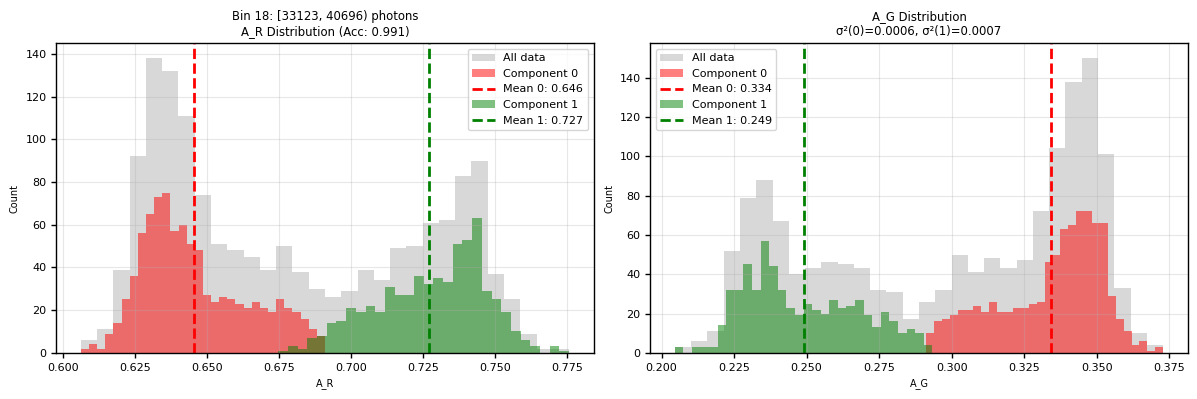

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.991
  Component accuracies: [ 0.99302  0.98858]

Bin 19/19: [40,696, 50,000) photons...
  Molecules in bin: 1287
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


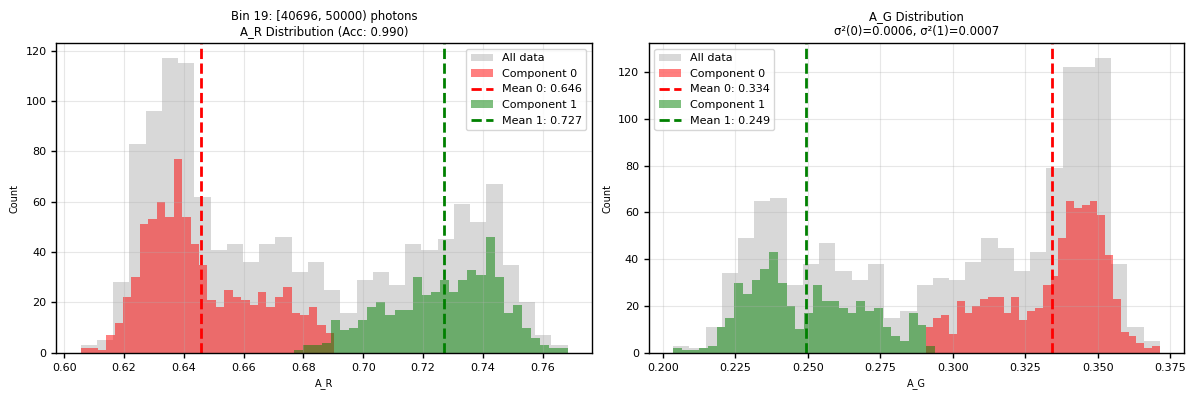

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.990
  Component accuracies: [ 0.99266  0.98693]

Analytical Analysis Complete!
Summary database: 19 bins
Overall accuracy range: 0.943 - 0.991

Analytical analysis complete:
  Summary: 19 photon bins
  Accuracy range: 0.943 - 0.991


In [64]:
# Step 2: Analytical misidentification analysis across photon bins
# For each photon bin:
#   1. Fit covariances with fixed means (M-estimators) - characterizes measurement noise robustly
#   2. Analytically calculate overlap/error rates from fitted distributions
# This separates signal (means) from noise (covariances) for better interpretation

photon_bins = np.logspace(np.log10(1000), np.log10(50000), 20)  # 2k to 200k photons, 20 bins

summary_analytical = SM_E.analyze_photon_dependent_misidentification_analytical(
    pa_db,
    fixed_means,
    ref_db,
    photon_bins,
    reference_covariances=gmm.covariances_,  # Use reference covariances from high-photon fit
    use_earliest_entry=True,
    estimator_type="tukey",  # Use Tukey bisquare (aggressive outlier down-weighting)
    max_iter=20,  # Maximum iterations for M-estimator re-weighting
    n_mc_samples=100000,  # Monte Carlo samples for analytical calculation
    verbose=True
)

print(f"\nAnalytical analysis complete:")
print(f"  Summary: {len(summary_analytical)} photon bins")
print(f"  Accuracy range: {summary_analytical['overall_accuracy'].min():.3f} - {summary_analytical['overall_accuracy'].max():.3f}")


In [62]:
summary_analytical

,photon_bin_min,photon_bin_max,n_molecules,converged,overall_accuracy,overall_error_rate,component_0_accuracy,component_0_error_rate,component_1_accuracy,component_1_error_rate,...,confusion_matrix_10,confusion_matrix_11,cov_0_AR_AR,cov_0_AR_AG,cov_0_AG_AG,weight_0,cov_1_AR_AR,cov_1_AR_AG,cov_1_AG_AG,weight_1
0,500.000000,693.459428,7,True,0.948329,0.051671,0.87704,0.12296,0.96021,0.03979,...,0.03979,0.96021,0.000330,-0.000313,0.000317,0.142857,0.005193,-0.004280,0.003762,0.857143
1,693.459428,961.771957,59,True,0.957286,0.042714,0.77422,0.22578,0.98193,0.01807,...,0.01807,0.98193,0.000748,-0.000662,0.000882,0.118644,0.000905,-0.000850,0.001060,0.881356
2,961.771957,1333.899663,289,True,0.945287,0.054713,0.77022,0.22978,0.97341,0.02659,...,0.02659,0.97341,0.000606,-0.000616,0.001069,0.138408,0.001191,-0.001027,0.001139,0.861592
3,1333.899663,1850.010596,686,True,0.957814,0.042186,0.79482,0.20518,0.98180,0.01820,...,0.01820,0.98180,0.000712,-0.000652,0.001029,0.128280,0.000956,-0.000803,0.000890,0.871720
4,1850.010596,2565.814580,1047,True,0.957119,0.042881,0.88268,0.11732,0.97613,0.02387,...,0.02387,0.97613,0.000690,-0.000558,0.000639,0.203438,0.000839,-0.000717,0.000787,0.796562
5,2565.814580,3558.576623,1530,True,0.969761,0.030239,0.93734,0.06266,0.98155,0.01845,...,0.01845,0.98155,0.000540,-0.000480,0.000574,0.266667,0.000598,-0.000509,0.000566,0.733333
6,3558.576623,4935.457021,2055,True,0.973517,0.026483,0.95356,0.04644,0.98218,0.01782,...,0.01782,0.98218,0.000510,-0.000440,0.000477,0.302676,0.000555,-0.000491,0.000538,0.697324
7,4935.457021,6845.078408,2496,True,0.980305,0.019695,0.96756,0.03244,0.98624,0.01376,...,0.01376,0.98624,0.000425,-0.000380,0.000417,0.317708,0.000470,-0.000424,0.000466,0.682292
8,6845.078408,9493.568319,2916,True,0.982892,0.017108,0.97547,0.02453,0.98700,0.01300,...,0.01300,0.98700,0.000405,-0.000366,0.000384,0.356310,0.000438,-0.000400,0.000435,0.643690
9,9493.568319,13166.808917,2992,True,0.985488,0.014512,0.98275,0.01725,0.98742,0.01258,...,0.01258,0.98742,0.000366,-0.000335,0.000347,0.413770,0.000406,-0.000381,0.000416,0.586230


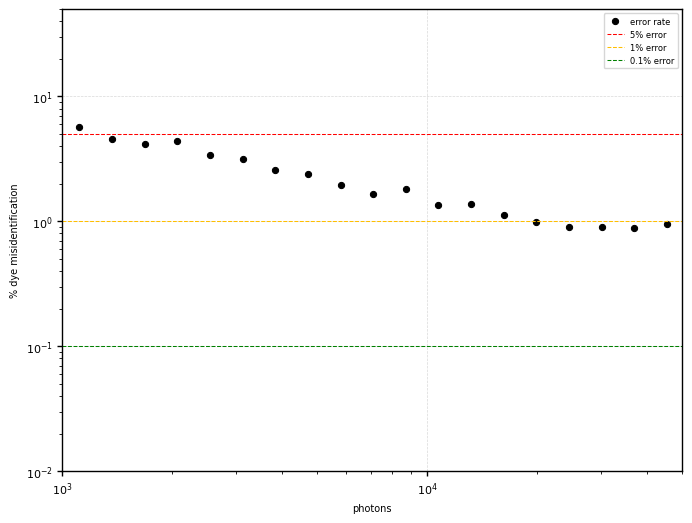

In [83]:
fig, axs = plotter.create_subplots()

axs = plotter.scatter_plot(axs, 0.5*(summary_analytical['photon_bin_min']+summary_analytical['photon_bin_max']), 100*(summary_analytical['overall_error_rate']),
                          xlabel='photons', ylabel=r'% dye misidentification', 
                          label='error rate')

axs.set_ylim([0.01, 50])
axs.hlines(y=5, xmin=1000, xmax=50000, ls='--', lw=0.75, color='red', label=r'5% error')
axs.hlines(y=1, xmin=1000, xmax=50000, ls='--', lw=0.75, color='#FFBF00', label=r'1% error')
axs.hlines(y=0.1, xmin=1000, xmax=50000, ls='--', lw=0.75, color='green', label=r'0.1% error')

axs.set_xlim([1000, 50000])

axs.set_yscale('log')
axs.set_xscale('log')
axs.legend(loc='best')
plt.savefig(os.path.join(folder, 'Dye_Error_Rate.svg'), dpi=600, format='svg')

plt.show()

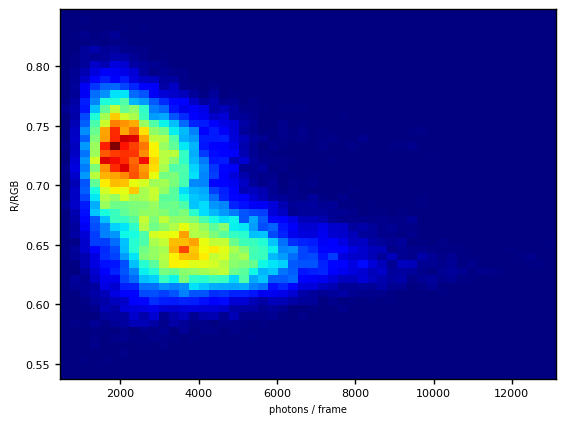

In [105]:
plt.hist2d(sf_db['photons'],sf_db['A_R'],50,cmap='jet')
plt.xlabel('photons / frame')
plt.ylabel('R/RGB')

#plt.savefig(os.path.join(folder, 'Brightness_R_heatmap.svg'), dpi=600, format='svg')

plt.show()

In [ ]:
# Diagnostic: Examine posterior distributions to understand outlier sensitivity
# Let's look at a specific photon bin to understand the fitting quality

# Choose a mid-range photon bin for analysis (e.g., around 10k photons)
test_bin_min = 10000
test_bin_max = 14000

# Filter data for this photon bin
bin_molecules = pa_db[
    (pa_db['molecular_index'].isin(ref_db['molecular_index'])) &
    (pa_db['photons_accumulated'] >= test_bin_min) &
    (pa_db['photons_accumulated'] < test_bin_max)
]

print(f"Analyzing photon bin: [{test_bin_min:,} - {test_bin_max:,}) photons")
print(f"Number of molecules: {len(bin_molecules)}")

# Extract A_R, A_G data
X = bin_molecules[['A_R', 'A_G']].values

# Get reference covariances from high-photon fit
ref_covariances = gmm.covariances_
print(f"\nReference covariances from high-photon fit (>25k photons):")
for k in range(len(fixed_means)):
    det = np.linalg.det(ref_covariances[k])
    print(f"  Component {k}: det={det:.6f}")
    print(f"    {ref_covariances[k]}")

# Fit covariances with fixed means using EM (standard approach)
covs_em, weights_em, converged_em = SM_E.fit_covariances_fixed_means(
    X, fixed_means, fit_type="EM", max_iter=100, verbose=True
)

print(f"\nFitted covariances at {test_bin_min:,}-{test_bin_max:,} photons (EM):")
for k in range(len(fixed_means)):
    det = np.linalg.det(covs_em[k])
    print(f"  Component {k}: det={det:.6f}")
    print(f"    {covs_em[k]}")

# Calculate determinant ratios
print(f"\nDeterminant ratios (low-photon / high-photon):")
for k in range(len(fixed_means)):
    ratio = np.linalg.det(covs_em[k]) / np.linalg.det(ref_covariances[k])
    print(f"  Component {k}: {ratio:.1f}x larger")

# Calculate posterior probabilities (responsibilities)
from scipy.stats import multivariate_normal
n_components = len(fixed_means)
responsibilities = np.zeros((len(X), n_components))

for k in range(n_components):
    responsibilities[:, k] = weights_em[k] * multivariate_normal.pdf(
        X, mean=fixed_means[k], cov=covs_em[k]
    )

# Normalize responsibilities
responsibilities /= responsibilities.sum(axis=1, keepdims=True)

# Get maximum posterior probability for each point
max_posteriors = responsibilities.max(axis=1)

# Visualize posterior distribution
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Histogram of maximum posterior probabilities
axs[0, 0].hist(max_posteriors, bins=50, edgecolor='black')
axs[0, 0].axvline(0.8, color='red', linestyle='--', label='80% confidence')
axs[0, 0].set_xlabel('Maximum Posterior Probability')
axs[0, 0].set_ylabel('Count')
axs[0, 0].set_title('Distribution of Assignment Confidence')
axs[0, 0].legend()

# Plot 2: Data colored by confidence
scatter = axs[0, 1].scatter(X[:, 0], X[:, 1], c=max_posteriors, cmap='viridis', 
                            s=10, alpha=0.5)
axs[0, 1].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20, 
               label='Fixed means')
axs[0, 1].set_xlabel('A_R')
axs[0, 1].set_ylabel('A_G')
axs[0, 1].set_title('Data colored by posterior confidence')
axs[0, 1].legend()
plt.colorbar(scatter, ax=axs[0, 1], label='Max posterior')

# Plot 3: Reference covariances from high-photon fit
from matplotlib.patches import Ellipse
def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
    """Plot covariance ellipse"""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellipse)

axs[0, 2].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, 2], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'Ref cov {k}')
axs[0, 2].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[0, 2].set_xlabel('A_R')
axs[0, 2].set_ylabel('A_G')
axs[0, 2].set_title(f'Reference Covariances (high-photon fit)')
axs[0, 2].legend()

# Plot 4: Fitted covariances (EM) - showing the problem
axs[1, 0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[1, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM cov {k}')
axs[1, 0].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[1, 0].set_xlabel('A_R')
axs[1, 0].set_ylabel('A_G')
axs[1, 0].set_title('Fitted Covariances (EM) - Current Method')
axs[1, 0].legend()

# Plot 5: Overlay both for comparison
axs[1, 1].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    # Reference (dashed)
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[1, 1], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, linestyle='--', label=f'Ref {k}')
    # Fitted (solid)
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[1, 1], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM {k}')
axs[1, 1].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[1, 1].set_xlabel('A_R')
axs[1, 1].set_ylabel('A_G')
axs[1, 1].set_title('Comparison: Reference (dashed) vs EM (solid)')
axs[1, 1].legend()

# Plot 6: Identify potential outliers using Mahalanobis distance from reference
outliers_mask = np.zeros(len(X), dtype=bool)
mahal_threshold = 3.0  # 3-sigma threshold

for i, x in enumerate(X):
    # Find closest component
    dists = []
    for k in range(n_components):
        diff = x - fixed_means[k]
        inv_cov = np.linalg.inv(ref_covariances[k])
        mahal = np.sqrt(diff @ inv_cov @ diff)
        dists.append(mahal)
    
    min_dist = min(dists)
    if min_dist > mahal_threshold:
        outliers_mask[i] = True

axs[1, 2].scatter(X[~outliers_mask, 0], X[~outliers_mask, 1], alpha=0.3, s=10, c='blue',
                  label=f'Inliers (<{mahal_threshold}σ from ref)')
axs[1, 2].scatter(X[outliers_mask, 0], X[outliers_mask, 1], alpha=0.8, s=30, c='red',
                  label=f'Outliers (>{mahal_threshold}σ from ref)')
for k in range(n_components):
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[1, 2], n_std=mahal_threshold,
                     edgecolor='green', facecolor='none', 
                     linewidth=2, linestyle='--')
axs[1, 2].plot(fixed_means[:, 0], fixed_means[:, 1], 'k*', markersize=20,
               label='Fixed means')
axs[1, 2].set_xlabel('A_R')
axs[1, 2].set_ylabel('A_G')
axs[1, 2].set_title(f'Outlier Detection using Mahalanobis (n={outliers_mask.sum()})')
axs[1, 2].legend()

plt.show()

# Statistics
print(f"\nPosterior Statistics:")
print(f"  Mean max posterior: {max_posteriors.mean():.3f}")
print(f"  Median max posterior: {np.median(max_posteriors):.3f}")
print(f"  % with >90% confidence: {100*(max_posteriors > 0.9).sum()/len(max_posteriors):.1f}%")
print(f"  % with >80% confidence: {100*(max_posteriors > 0.8).sum()/len(max_posteriors):.1f}%")
print(f"  % with <50% confidence: {100*(max_posteriors < 0.5).sum()/len(max_posteriors):.1f}%")
print(f"\nOutlier Statistics (Mahalanobis distance from reference):")
print(f"  % outliers (>{mahal_threshold}σ): {100*outliers_mask.sum()/len(outliers_mask):.1f}%")

In [ ]:
# Test robust fitting method and compare with standard EM
print("="*60)
print("Testing Robust Fitting Method")
print("="*60)

# Test with different Mahalanobis thresholds
thresholds = [2.0, 3.0, 4.0]

fig, axs = plt.subplots(2, len(thresholds)+1, figsize=(6*(len(thresholds)+1), 12))

# Plot 0: Standard EM (for comparison)
axs[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[0, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM {k}')
    # Also show reference as dashed
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=1, linestyle='--', alpha=0.5)
axs[0, 0].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20)
axs[0, 0].set_xlabel('A_R')
axs[0, 0].set_ylabel('A_G')
axs[0, 0].set_title('Standard EM\n(dashed = reference)')
axs[0, 0].legend()

# Determinant comparison
dets_em = [np.linalg.det(covs_em[k]) for k in range(n_components)]
dets_ref = [np.linalg.det(ref_covariances[k]) for k in range(n_components)]
ratios_em = [dets_em[k] / dets_ref[k] for k in range(n_components)]

axs[1, 0].bar([f'Comp {k}' for k in range(n_components)], ratios_em, color=['blue', 'orange'])
axs[1, 0].axhline(1.0, color='green', linestyle='--', label='Reference')
axs[1, 0].set_ylabel('Det ratio (fitted / ref)')
axs[1, 0].set_title('Standard EM: Covariance Size Ratio')
axs[1, 0].legend()

# Test robust fitting with different thresholds
for i, threshold in enumerate(thresholds, 1):
    print(f"\nTesting threshold = {threshold}σ:")
    
    covs_robust, weights_robust, converged_robust = SM_E.fit_covariances_fixed_means_robust(
        X, fixed_means, 
        reference_covariances=ref_covariances,
        mahalanobis_threshold=threshold,
        max_iter=10,
        verbose=True
    )
    
    # Plot fitted covariances
    axs[0, i].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
    for k in range(n_components):
        plot_cov_ellipse(covs_robust[k], fixed_means[k], axs[0, i], n_std=2.0,
                         edgecolor=['blue', 'orange'][k], facecolor='none', 
                         linewidth=2, label=f'Robust {k}')
        # Also show reference as dashed
        plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, i], n_std=2.0,
                         edgecolor=['blue', 'orange'][k], facecolor='none', 
                         linewidth=1, linestyle='--', alpha=0.5)
    axs[0, i].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20)
    axs[0, i].set_xlabel('A_R')
    axs[0, i].set_ylabel('A_G')
    axs[0, i].set_title(f'Robust ({threshold}σ threshold)\n(dashed = reference)')
    axs[0, i].legend()
    
    # Determinant comparison
    dets_robust = [np.linalg.det(covs_robust[k]) for k in range(n_components)]
    ratios_robust = [dets_robust[k] / dets_ref[k] for k in range(n_components)]
    
    axs[1, i].bar([f'Comp {k}' for k in range(n_components)], ratios_robust, color=['blue', 'orange'])
    axs[1, i].axhline(1.0, color='green', linestyle='--', label='Reference')
    axs[1, i].set_ylabel('Det ratio (fitted / ref)')
    axs[1, i].set_title(f'Robust ({threshold}σ): Covariance Size Ratio')
    axs[1, i].legend()

plt.show()

print("\n" + "="*60)
print("Summary: Determinant Ratios (Fitted / Reference)")
print("="*60)
print(f"{'Method':<20} {'Component 0':<15} {'Component 1':<15}")
print("-"*60)
print(f"{'Standard EM':<20} {ratios_em[0]:<15.2f} {ratios_em[1]:<15.2f}")
for threshold in thresholds:
    covs_robust, _, _ = SM_E.fit_covariances_fixed_means_robust(
        X, fixed_means, ref_covariances, threshold, max_iter=10, verbose=False
    )
    dets = [np.linalg.det(covs_robust[k]) for k in range(n_components)]
    ratios = [dets[k] / dets_ref[k] for k in range(n_components)]
    print(f"{'Robust (' + str(threshold) + 'σ)':<20} {ratios[0]:<15.2f} {ratios[1]:<15.2f}")

print("\nIdeal ratio should be close to 1.0 (matching reference covariances)")
print("Lower ratios = tighter fit, less influenced by outliers")

In [ ]:
# different implementation: take the highest photon data and get the centres, then fit the widths at each photon bin.
# Then use the fact the data are normally distributed to calculate the analytical false positive rates.

# this is an example of linking molecules with HDBSCAN ###

In [ ]:
single_molecule_database, single_frame_database = SM_E.extract_single_molecules_HDBSCAN(
    localisation_files,
    min_cluster_size=min_cluster_size,
    max_localization_error=max_localization_error,
    min_photons=min_photons,
    max_photons=max_photons,
)

# this is an example of linking molecules with DBSCAN

In [ ]:
single_molecule_database, single_frame_database = SM_E.extract_single_molecules_DBSCAN(
    pd.read_hdf(localisation_files[0]),
    min_cluster_size=min_cluster_size,
    max_localization_error=max_localization_error,Dye
    min_photons=min_photons,
    chi_val=chi_val,
    max_photons=max_photons,
)

In [ ]:
molecules_to_remove = single_molecule_database['molecular_index'][single_molecule_database['A_R'] > 0.8]

In [ ]:
single_molecule_database = single_molecule_database[single_molecule_database['A_R'] < 0.8]
single_frame_database =

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])



plt.hist((single_molecule_database['A_R']), 200);
plt.show()

# this is an example of linking molecules sequentially

In [ ]:
extract_single_molecules_linked = SM_E.extract_single_molecules_linked(
    localisation_files,
    max_distance=max_distance,
    max_localization_error=max_localization_error,
    min_photons=min_photons,
    max_photons=max_photons,
)